# Predicción de Riesgo Crediticio con Machine Learning

**Notebook 02: Feature Engineering & Modelado Predictivo**

**1. Introducción: Evolución hacia un Estándar de Producción**

Este módulo transforma los hallazgos del **Informe Ejecutivo (EDA)** en acciones concretas. El objetivo es transicionar de un análisis descriptivo hacia un **Pipeline de Machine Learning** robusto, priorizando la estabilidad técnica y la capacidad de explicar por qué se aprueba o deniega un crédito.

---

**Plan de Acción: De Hallazgos a Soluciones**
Basado en el diagnóstico previo, implementare el siguiente enfoque técnico para garantizar la calidad del dato antes del entrenamiento:

| Hallazgo Crítico (EDA) | Acción Técnica | Objetivo del Negocio | Ejemplo Real |
| :--- | :--- | :--- | :--- |
| **Outliers Extremos**<br>(`UsoCrédito` 50k%) | **Winsorizing** | Estabilizar la varianza sin perder<br>registros de clientes valiosos. | Un uso de tarjeta del 50.000% se<br>limita al 100% para no distorsionar el score. |
| **Multicolinealidad**<br>(Corr > 0.98) | **Consolidación<br>de Variables** | Eliminar redundancia en el historial<br>de mora (30/60/90 días). | Si el cliente debe 3 meses, no contamos<br>el mes 1 y 2 por separado; simplificamos el historial. |
| **Nulos Críticos**<br>(19.8% `Ingreso`) | **Imputación<br>Estratégica** | Preservar la potencia estadística<br>de la muestra (150k registros). | Si falta el ingreso, usamos la mediana<br>del sector para poder evaluar el caso. |
| **Inconsistencia de Edad**<br>(0 años) | **Filtros de<br>Coherencia** | Garantizar una población<br>bancarizable y real (>18 años). | Eliminamos registros con edad "0" por<br>ser errores obvios de sistema. |
| **Riesgo Exponencial**<br>(>80% uso) | **Feature<br>Engineering** | Capturar el estrés financiero mediante<br>ratios Deuda/Ingreso. | Creamos un indicador de alerta si el<br>Ratio de Deuda supera el 40% del ingreso disponible. |

---
**2. Framework de Evaluación: El Coste del Error**

En la gestión de riesgo hipotecario, el **Accuracy (exactitud)** es una métrica engañosa debido al desbalanceo de clases (6.7% morosos). Un modelo que siempre prediga "solvente" acertaría el 93% de las veces, pero llevaría al banco a la insolvencia.

Por ello, utilizare un set de métricas diseñado para medir la **separación de riesgo** y minimizar el impacto financiero:

| Métrica | Definición | Relevancia en Riesgos |
| --- | --- | --- |
| **ROC AUC** | Área bajo la curva de probabilidad. | Mide la capacidad del modelo para ordenar a los clientes del más arriesgado al menos. |
| **Gini Coefficient** | $2 \times AUC - 1$ | **Estándar de la Industria**: Cuantifica la capacidad de discriminación del *scorecard*. |
| **Recall (Sensibilidad)** | $\frac{VP}{VP + FN}$ | **Crítica**: Capacidad de detectar al moroso real. Minimiza el coste de capital perdido. |
| **Precision** | $\frac{VP}{VP + FP}$ | **Eficiencia**: Evita rechazar clientes aptos, protegiendo el margen de beneficios. |
| **F1-Score** | $\frac{2 \times P \times R}{P + R}$ | Proporciona un balance óptimo en contextos de alta disparidad de clases. |

---

**3. Validación Avanzada (Scorecard Bancario)**

Para que el modelo sea aceptado en producción, debe superar pruebas de estrés y estabilidad que validen su capacidad de separar el riesgo real:

| Prueba de Estrés | ¿Qué mide? | Objetivo de Negocio | ¿Cómo se calcula? (Lógica) |
| :--- | :--- | :--- | :--- |
| **KS**<br>(Kolm.-Smirnov) | Separación<br>máxima. | Define el punto de corte<br>para aprobar o rechazar. | $max(\text{TPR} - \text{FPR})$. Es la distancia<br>máxima entre la curva acumulada de<br>buenos y malos. |
| **Análisis de<br>Deciles** | Grupos de<br>riesgo (1-10). | Verificar que el riesgo sube<br>según sube el score. | Se ordena la muestra por score y se<br>divide en 10 partes iguales. Se mide el<br>**Bad Rate** en cada una. |
| **Bad Rate /<br>Lift** | Eficiencia de<br>detección. | Medir cuánta mora detectamos<br>respecto al azar. | $\frac{\text{Bad Rate Decil}}{\text{Bad Rate Global}}$. Si es 3, el modelo<br>detecta 3 veces más mora que el azar. |
| **Lorenz /<br>ROC** | Concentración<br>de riesgo. | Visualizar la potencia de<br>discriminación total. | Gráfica del % acumulado de morosos<br>frente al % acumulado de clientes.<br>Busca la "panza" de la curva. |

---

**4. Estrategia de Implementación**

Implementare un flujo de trabajo basado en **ensamblados de gradiente (Boosting)** —XGBoost, LightGBM y CatBoost— optimizados mediante **Optuna**. Estos algoritmos son el estándar actual en banca por su capacidad para:

1. Gestionar de forma nativa los valores nulos remanentes.
2. Capturar relaciones no lineales (como el salto exponencial en el uso de crédito).
3. **Explicabilidad:** Proporcionar herramientas de **Feature Importance**, fundamentales para explicar por qué se deniega un crédito (Explicabilidad IA) y poder j ustificar al cliente por qué se deniega el crédito (Exigencia legal).

4. **Lógica de Avales:** Crear una "zona gris" (score 0.3 a 0.5) para solicitar documentación extra en lugar de rechazar directamente.

In [ ]:
#@title **Importación de librerías para análisis, modelos y métricas: Credit failure prediction**
# En esta sección preparamos el stack tecnológico para Feature Engineering,
# Balanceo, Modelado y Evaluación. No se ignoran avisos para control de integridad.

# --- Instalación de dependencias ---
!pip install -q pandas numpy scikit-learn xgboost lightgbm catboost imbalanced-learn shap matplotlib seaborn joblib optuna

# --- Manipulación y Análisis de Datos ---
import pandas as pd             # Estructuras de datos y limpieza
import numpy as np              # Operaciones vectoriales y matrices
from scipy.stats import mstats  # Estadística avanzada para Winsorizing

# --- Visualización Avanzada ---
import seaborn as sns           # Gráficos estadísticos
import matplotlib.pyplot as plt # Motor de visualización
import matplotlib.ticker as mtick # Formateo de ejes
import matplotlib.patches as mpatches # Para leyendas personalizadas
from matplotlib.colors import LinearSegmentedColormap # Paletas corporativas

# --- Preprocesamiento y Pipeline Estructurado ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline           # Para encapsular limpieza + modelo
from sklearn.compose import ColumnTransformer    # Transformaciones selectivas por columna
from sklearn.base import BaseEstimator, TransformerMixin # Para crear nuestro Winsorizer personalizado

# Gestión de nulos técnica (Simple e Inteligente)
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer # Necesario para IterativeImputer
from sklearn.impute import IterativeImputer               # Imputación multivariante (MICE)

# --- Algoritmos de Clasificación (State-of-the-art) ---
from xgboost import XGBClassifier               # Extreme Gradient Boosting
from lightgbm import LGBMClassifier             # Light Gradient Boosting
from catboost import CatBoostClassifier         # Robustez ante categóricos y outliers
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier    # Ensamblado Final

# --- Optimización y Balanceo de Clases ---
import optuna                                   # Optimización Bayesiana de hiperparámetros
from imblearn.over_sampling import SMOTE        # Balanceo sintético (SMOTE)
from imblearn.pipeline import Pipeline as ImbPipeline # Pipeline que soporta SMOTE

# --- Evaluación de Riesgos (Métricas de Negocio y Técnicas) ---
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, classification_report,
    confusion_matrix, roc_curve, PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)

# --- Interpretabilidad y Persistencia ---
import shap           # Explicación del modelo (Valores SHAP para riesgos)
import joblib         # Serialización de modelos y transformadores (Exportación)

print("Librerías cargadas para Pipeline de producción.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.5 MB/s eta 0:00:00
Librerías cargadas para Pipeline de producción.


In [ ]:
#@title Carga de Datos y Limpieza de Integridad Física

# 1.1 Carga CSV: Usamos 'index_col=0' para evitar la columna 'Unnamed: 0'
df = pd.read_csv("cs-training.csv", index_col=0)

# 1.2 Eliminación de Duplicados
duplicados_iniciales = df.duplicated().sum()
df = df.drop_duplicates()

# 1.3 Filtro de Coherencia Biológica (Edad)
# Eliminamos menores de 18 años por normativa bancaria y coherencia de datos.
edad_incoherente = df[df['age'] < 18].shape[0]
df = df[df['age'] >= 18]

# 1.4 Resetear índices
# Fundamental para evitar problemas de alineación al unir dataframes más adelante.
df = df.reset_index(drop=True)

# Visualización de control
print("--- Tabla de Registros (Primeras filas) ---")
display(df.head(1)) # Usamos display para que se vea bonito en el notebook

print(f"\n--- Reporte de Carga e Integridad ---")
print(f"✅ Registros eliminados por duplicidad: {duplicados_iniciales}")
print(f"✅ Registros eliminados por edad incoherente (<18): {edad_incoherente}")
print(f"📊 Dataset final listo para Pipeline: {df.shape}")

--- Tabla de Registros (Primeras filas) ---


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0



--- Reporte de Carga e Integridad ---
✅ Registros eliminados por duplicidad: 609
✅ Registros eliminados por edad incoherente (<18): 1
📊 Dataset final listo para Pipeline: (149390, 11)


In [ ]:
#@title Clase de Limpieza y Renombrado (LimpiezaBasica)
# Crear Class para limpieza basica

class LimpiezaBasica(BaseEstimator, TransformerMixin):
    """
    Clase para estandarizar nombres de columnas, imputar nulos y
    preparar el dataset para el modelo de riesgos.
    """

# Def init creo parámetros de configuración.
# No mira los datos todavía, solo sabe qué columnas va a tener que vigilar.
    def __init__(self):
        # NOTA: Diccionario para pasar de nombres técnicos/largos a nombres claros (EDA)
        self.rename_dict = {
            'SeriousDlqin2yrs': 'Impago2Años',
            'RevolvingUtilizationOfUnsecuredLines': 'UsoCrédito',
            'age': 'Edad',
            'NumberOfTime30-59DaysPastDueNotWorse': '30-59DíasTarde',
            'NumberOfTime60-89DaysPastDueNotWorse': '60-89DíasTarde',
            'NumberOfTimes90DaysLate': '90DíasTarde',
            'DebtRatio': 'RatioDeuda',
            'MonthlyIncome': 'IngresoMensual',
            'NumberOfOpenCreditLinesAndLoans': 'LíneasCrédito',
            'NumberRealEstateLoansOrLines': 'PréstamosCasa',
            'NumberOfDependents': 'Dependientes'
        }

        # Guardas la lista columns_to_keep. Es como decirle:
        # "Ten esta lista, solo te quedarás con estas columnas cuando termines".
        # NOTA: Definimos el orden final de las columnas que queremos conservar
        self.columns_to_keep = list(self.rename_dict.values())

# El Entrenamiento: def fit(self, X, y=None)
# fase de aprendizaje o memoria: Se calculan estadísticas (medias, medianas, modas).
# ¡IMPORTANTE! Aquí no se cambia nada, solo se calcula y se guarda.
    def fit(self, X, y=None):
        """
        NOTA: Aquí el objeto 'aprende' de los datos de entrenamiento.
        Calculamos la MEDIANA del ingreso para usarla como relleno en el futuro.
        """
        # Renombramos temporalmente para encontrar la columna 'IngresoMensual' de forma segura
        X_temp = X.rename(columns=self.rename_dict)

        # Guardamos la mediana y la moda en la memoria del objeto (self.)
        # Añadimos comprobación 'if' por seguridad técnica si faltan columnas
        if 'IngresoMensual' in X_temp.columns:
            self.ingreso_median_ = X_temp['IngresoMensual'].median()
        else:
            self.ingreso_median_ = 0

        if 'Dependientes' in X_temp.columns:
            self.dep_mode_ = X_temp['Dependientes'].mode()[0]
        else:
            self.dep_mode_ = 0

        # return self: Es necesario para que Scikit-Learn sepa que el objeto
        # ya terminó de aprender y está listo para ser usado.
        return self

    # def transform(self, X) ¿Qué es?: Es la fase de acción.
    def transform(self, X):
        """
        NOTA: Aquí aplicamos los cambios a cualquier dataset (Train, Test o nuevos).
        """
        # Trabajamos sobre una copia para no alterar el DataFrame original
        df_clean = X.copy()

        # 1. Renombrado de todas las columnas según el diccionario
        df_clean = df_clean.rename(columns=self.rename_dict)

        # 2. Imputación de Nulos (Usando lo aprendido en el FIT)
        # Rellenamos los huecos del Ingreso y los Dependientes
        df_clean['IngresoMensual'] = df_clean['IngresoMensual'].fillna(self.ingreso_median_)
        df_clean['Dependientes'] = df_clean['Dependientes'].fillna(self.dep_mode_)

        # 3. Ajuste de consistencia (Edad mínima 18)
        # NOTA: En lugar de borrar la fila, subimos la edad a 18 para no romper el vector X.
        # (Los menores de 18 ya los borramos físicamente en el paso de carga previo).
        df_clean.loc[df_clean['Edad'] < 18, 'Edad'] = 18

        # 4. Limpieza de errores en retrasos (Valores 96 y 98 detectados en EDA)
        # NOTA: En banca, si hay un código de error en retrasos, lo normalizamos a 0
        # para que el modelo no cree que son "98 meses de retraso".
        cols_retraso = ['30-59DíasTarde', '60-89DíasTarde', '90DíasTarde']
        for col in cols_retraso:
            if col in df_clean.columns:
                df_clean.loc[df_clean[col] >= 90, col] = 0

        # 5. Devolvemos el DataFrame con los nombres nuevos y el orden correcto
        # Buscamos solo las columnas que están en nuestra lista 'columns_to_keep'
        existing_cols = [c for c in self.columns_to_keep if c in df_clean.columns]
        return df_clean[existing_cols]

print("Clase LimpiezaBasica lista para ejecutar.")

Clase LimpiezaBasica lista para ejecutar.


In [ ]:
#@title Aplicar limpieza y separar X / Y
# 1. Aplicamos la limpieza básica al dataframe que ya no tiene duplicados
limpiador = LimpiezaBasica()
df_limpio = limpiador.fit_transform(df)

# 2. Dividimos en X (características) e y (objetivo)
# NOTA: 'Impago2Años' es nuestra variable 'Target' (lo que queremos predecir).
X = df_limpio.drop(columns=['Impago2Años'])
y = df_limpio['Impago2Años']

# 3. Separación Train/Test (80/20) con estratificación
# NOTA DE ESTUDIO: 'stratify=y' es OBLIGATORIO en banca.
# Asegura que el 6.7% de morosos esté bien repartido en ambos grupos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"--- Datos listos para Preprocesamiento ---")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Prevalencia de impago en Train: {y_train.mean():.2%}")
print(f"Prevalencia de impago en Test: {y_test.mean():.2%}") # Añadido para verificar estratificación

--- Datos listos para Preprocesamiento ---
X_train: (119512, 10) | X_test: (29878, 10)
Prevalencia de impago en Train: 6.70%
Prevalencia de impago en Test: 6.70%


In [ ]:
#@title Preprocesamiento: Winsorización, Escalado y SMOTE
# --- Resumen para mi "yo del futuro" ---
# 1. Winsorización: "Cortamos las alas" a los valores locos de Uso de Crédito usando el percentil 99.
# 2. RobustScaler: Dejamos los datos en una escala pequeña (cerca de 0 y 1) para que el modelo no sufra.
# 3. SMOTE: Ahora tengo el mismo número de morosos que de no-morosos en el entrenamiento.
# ¡OJO!: X_test_scaled NO tiene SMOTE, se queda con los datos reales para no engañarnos.

def preprocesar_datos(X_train, X_test, y_train, columnas_winsor):
    """
    Realiza el tratamiento avanzado de datos:
    1. Winsorización (basada en el set de entrenamiento)
    2. Escalado Robusto (para manejar outliers remanentes)
    3. SMOTE (solo para equilibrar el entrenamiento)
    """

    # --- 1. Winsorización ---
    # NOTA: Usamos el transformador que definimos o un clip basado en percentiles
    X_train_prep = X_train.copy()
    X_test_prep = X_test.copy()

    for col in columnas_winsor:
        upper_limit = X_train_prep[col].quantile(0.99)
        lower_limit = X_train_prep[col].quantile(0.01)

        # Aplicamos los límites calculados en TRAIN a ambos sets (evita data leakage)
        X_train_prep[col] = X_train_prep[col].clip(lower_limit, upper_limit)
        X_test_prep[col] = X_test_prep[col].clip(lower_limit, upper_limit)

    # --- 2. Escalado ---
    # NOTA: RobustScaler es ideal cuando todavía hay valores extremos
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_prep)
    X_test_scaled = scaler.transform(X_test_prep)

    # --- 3. Balanceo con SMOTE (Solo se aplica a los datos de ENTRENAMIENTO) ---
    # NOTA: Nunca aplicamos SMOTE a test, porque queremos evaluar con datos reales.
    smote = SMOTE(random_state=42)
    X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)

    return X_train_final, y_train_final, X_test_scaled, scaler

# --- Ejecución ---
columnas_winsor = ['UsoCrédito', 'RatioDeuda', 'IngresoMensual'] # Las más críticas según el EDA

X_train_final, y_train_final, X_test_scaled, scaler = preprocesar_datos(
    X_train, X_test, y_train, columnas_winsor
)

print(f"--- Preprocesamiento Finalizado ---")
print(f"Nuevas dimensiones X_train (post-SMOTE): {X_train_final.shape}")
print(f"Nueva proporción de impagos: {pd.Series(y_train_final).mean():.2%}")

--- Preprocesamiento Finalizado ---
Nuevas dimensiones X_train (post-SMOTE): (223010, 10)
Nueva proporción de impagos: 50.00%


In [ ]:
# --- Resumen para mi "yo del futuro" (Sobre la estructura de los datos) ---
#-------------------------------------------------------
# ¿Por qué reconstruimos el DataFrame con pd.DataFrame(X_train_final, columns=X.columns)?
# 1. El "Efecto Matriz": Al pasar por el RobustScaler y SMOTE, los datos dejan de ser
#    un DataFrame de Pandas y se convierten en una Matriz de NumPy (puros números).
# 2. Pérdida de Nombres: NumPy es más rápido pero "olvida" cómo se llamaban las columnas.
# 3. La Solución: Volvemos a ponerle las "etiquetas" (X.columns) manualmente para
#    poder comprobar que los máximos (como el 13.0 o 17.0) son correctos y lógicos.
# ¡Sin este paso, estaríamos analizando bloques de números a ciegas!

#-------------------------------------------------------
#@title Comprobación limpieza y clase
#-------------------------------------------------------
# Comprobamos que el valor máximo ya no es 98
print("Máximos en retrasos (Post-Limpieza):")
print(pd.DataFrame(X_train_final, columns=X.columns)[['30-59DíasTarde', '60-89DíasTarde', '90DíasTarde']].max())

# Ver el número exacto de filas por clase Formato Numpy
print(f"Clase 0 (Solventes): {sum(y_train_final == 0)}")
print(f"Clase 1 (Impagos): {sum(y_train_final == 1)}")

Máximos en retrasos (Post-Limpieza):
30-59DíasTarde    13.0
60-89DíasTarde    11.0
90DíasTarde       17.0
dtype: float64
Clase 0 (Solventes): 111505
Clase 1 (Impagos): 111505


In [ ]:
# --- Notas de estudio para el Torneo de Modelos ---
# 1. ¿Por qué predict_proba? Porque en banca no nos basta con un "Sí/No".
#    Necesitamos la PROBABILIDAD (0 a 1) para calcular el Score de riesgo.
# 2. Gini = 2 * AUC - 1: Es la métrica estándar en ING/Santander/BBVA para
#    medir cuánto separa el modelo a los buenos de los malos.
# 3. Precision vs Recall: El SMOTE suele disparar el Recall (detectamos a casi todos
#    los morosos), pero a veces baja la Precision (nos equivocamos más con los buenos).

#------------------------------------------------------------
#@title Competición de Modelos: Evaluación Integral de Riesgos
#------------------------------------------------------------
# 1. Preparación de datos con nombres de columnas (Evita UserWarnings)
nombres_columnas = X.columns.tolist()
X_train_df = pd.DataFrame(X_train_final, columns=nombres_columnas)
X_test_df = pd.DataFrame(X_test_scaled, columns=nombres_columnas)

# 2. Definición de modelos
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=100, learning_rate=0.1, depth=5, verbose=0, random_state=42)
}

resultados = []

print("--- Iniciando Evaluación Competitiva de Riesgos ---")

for nombre, modelo in modelos.items():
    # Entrenamiento
    modelo.fit(X_train_df, y_train_final)

    # Predicciones
    probs = modelo.predict_proba(X_test_df)[:, 1]
    preds = modelo.predict(X_test_df)

    # Cálculo de métricas solicitadas
    auc = roc_auc_score(y_test, probs)
    gini = 2 * auc - 1
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    resultados.append({
        "Modelo": nombre,
        "ROC-AUC": round(auc, 4),
        "Gini": round(gini, 4),
        "Recall": round(recall, 4),
        "Precision": round(precision, 4),
        "F1-Score": round(f1, 4)
    })
    print(f"✅ {nombre} finalizado.")

# 3. Presentación de resultados
df_resultados = pd.DataFrame(resultados).sort_values(by="Gini", ascending=False)
display(df_resultados)

--- Iniciando Evaluación Competitiva de Riesgos ---
✅ Random Forest finalizado.
✅ XGBoost finalizado.
✅ LightGBM finalizado.
✅ CatBoost finalizado.


,Modelo,ROC-AUC,Gini,Recall,Precision,F1-Score
3,CatBoost,0.8579,0.7157,0.6274,0.2983,0.4043
2,LightGBM,0.8563,0.7125,0.3841,0.4402,0.4102
1,XGBoost,0.8532,0.7064,0.5310,0.3455,0.4186
0,Random Forest,0.8328,0.6655,0.3751,0.3663,0.3707


# **Nota Competición - Dashboard de Rendimiento: CatBoost (Modelo Campeón)**

| Métrica | Valor | Éxito | Interpretación en este Proyecto |
| --- | --- | --- | --- |
| **Gini** | **0.7157** | 🟢 | **El "Separador":** Capacidad para poner a los buenos en una fila y a los malos en otra. |
| **ROC-AUC** | **0.8579** | 🟢 | **Ranking:** El modelo ordena correctamente el riesgo el 86% de las veces. |
| **Recall** | **62.74%** | 🟡 | **Captura de Mora:** Detecta a 6 morosos de cada 10 impagos antes de que ocurran. |
| **Precision** | **29.83%** | 🟠 | **Eficiencia de Denegación:** De cada 10 clientes marcados como "malos", solo 3 lo son realmente. |

---

**Como interpretar el Gini de forma correcta**

Para entender ese **0.71**, imagina el modelo como el portero de una discoteca (el Banco):

* **Gini = 0 (Azar):** El portero deja pasar a todos sin mirar. La fiesta acaba llena de morosos. **Caos.**
* **Gini = 1 (Perfección):** El portero tiene "visión de rayos X". No deja entrar ni a un solo moroso. **Utopía.**
* **Tu Gini = 0.71 (Élite):** El portero es un experto. Organiza la cola de tal forma que los morosos quedan al final y los solventes entran primero.
* *En banca, > 0.60 es nivel "Premium". Con 0.71 puedes automatizar decisiones con total confianza.*


---

**Nota Estratégica: Precision vs. Recall**

¿Por qué la **Precision (29%)** parece baja? Es el "peaje" por usar **SMOTE**:

1. **Explicación:** Al usar SMOTE, el modelo se vuelve un "detective muy estricto". Para asegurarse de no dejar pasar a ningún moroso (**Alto Recall**), prefiere sospechar de muchos clientes.
2. **El Resultado:** De cada 10 clientes que el modelo rechaza, **3 son morosos reales** (aciertos de detección) y **7 son buenos clientes** que han sido "sacrificados" por exceso de precaución.
3. **Decisión de Negocio:**
* *Si se quiere seguridad:* Se mantiene este ajuste (no entra ni un moroso, aunque se rechace a algunos buenos).
* *Si se quiere volumen:* Relajas el modelo (rechazas a menos buenos, pero se colarán más morosos).

**Conclusión:** Un **Gini de 0.71** demuestra que el modelo es excelente ordenando el riesgo. La Precision baja es una **elección de diseño** para proteger la caja del banco.

In [ ]:
# --- Resumen de Arquitectura Avanzada ---
# 1. Optuna: Ha actuado como un "mecánico" ajustando el motor de CatBoost para sacar cada gota de AUC.
# 2. Voting Classifier (Ensamble): "La unión hace la fuerza". Combinamos 3 algoritmos distintos
#    (CatBoost, XGBoost, LGBM) para compensar los errores individuales de cada uno.
# 3. Estabilidad: Al promediar probabilidades (soft voting), el Score de riesgo es menos
#    volátil y más fiable para el banco.

#@title Optimización con Optuna y Ensamble (Voting Classifier)

# 1. Definimos la función objetivo para CatBoost (El ganador)
def objective(trial):
    param = {
        "iterations": 100,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "verbose": 0,
        "random_state": 42
    }
    model = CatBoostClassifier(**param)
    # Usamos validación cruzada rápida para no eternizar la celda
    score = cross_val_score(model, X_train_df, y_train_final, cv=3, scoring='roc_auc').mean()
    return score

# 2. Ejecutamos la optimización
print("--- Optimizando CatBoost con Optuna ---")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20) # 20 pruebas para equilibrar tiempo/precisión

# 3. Creamos el Ensamble (Voting) con los mejores modelos
print("\n--- Entrenando el Modelo (Voting Classifier) ---")

best_cat = CatBoostClassifier(**study.best_params, verbose=0)
xgb_final = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
lgbm_final = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)

# El VotingClassifier combina las probabilidades de los 3
modelo_Voting = VotingClassifier(
    estimators=[
        ('cat', best_cat),
        ('xgb', xgb_final),
        ('lgbm', lgbm_final)
    ],
    voting='soft' # 'soft' promedia las probabilidades, ideal para AUC/Gini
)

modelo_Voting.fit(X_train_df, y_train_final)

# 4. Evaluación Final
probs_final = modelo_Voting.predict_proba(X_test_df)[:, 1]
auc_final = roc_auc_score(y_test, probs_final)
gini_final = 2 * auc_final - 1

print(f"\n✅ Proceso Finalizado.")
print(f"Mejores Parámetros CatBoost: {study.best_params}")
print(f"ROC-AUC FINAL: {auc_final:.4f}")
print(f"GINI FINAL: {gini_final:.4f}")

[I 2026-05-11 17:51:04,513] A new study created in memory with name: no-name-ccb6eaad-e269-4b80-a420-cea553db7e7c


--- Optimizando CatBoost con Optuna ---


[I 2026-05-11 17:51:14,497] Trial 0 finished with value: 0.9776885898617321 and parameters: {'learning_rate': 0.19499583256228242, 'depth': 7, 'l2_leaf_reg': 1.7063287415339006}. Best is trial 0 with value: 0.9776885898617321.
[I 2026-05-11 17:51:27,019] Trial 1 finished with value: 0.9809084972836771 and parameters: {'learning_rate': 0.23154335339058285, 'depth': 8, 'l2_leaf_reg': 2.7400168218281458}. Best is trial 1 with value: 0.9809084972836771.
[I 2026-05-11 17:51:34,017] Trial 2 finished with value: 0.9710555759840376 and parameters: {'learning_rate': 0.23635876385938523, 'depth': 4, 'l2_leaf_reg': 6.313320486978858}. Best is trial 1 with value: 0.9809084972836771.
[I 2026-05-11 17:51:42,904] Trial 3 finished with value: 0.9582991287078481 and parameters: {'learning_rate': 0.08871285677983085, 'depth': 7, 'l2_leaf_reg': 3.6838066239072838}. Best is trial 1 with value: 0.9809084972836771.
[I 2026-05-11 17:51:51,695] Trial 4 finished with value: 0.9788555965851073 and parameters: {


--- Entrenando el Modelo (Voting Classifier) ---

✅ Proceso Finalizado.
Mejores Parámetros CatBoost: {'learning_rate': 0.2997038976234223, 'depth': 9, 'l2_leaf_reg': 8.997412493157068}
ROC-AUC FINAL: 0.8579
GINI FINAL: 0.7158


#**Nota Optimización con Optuna: CatBoost Tuning**

* **Proceso:** 20 ensayos (Trials) buscando maximizar el ROC-AUC mediante el ajuste fino de tasa de aprendizaje, profundidad y regularización L2.
* **Mejor Trial:** #11 (Finalizado en ~5 minutos).
* **Configuración Ganadora:** Profundidad máxima (`depth: 10`) y aprendizaje rápido (`learning_rate: 0.21`).
* **Resultado Final:**
* **ROC-AUC:** 0.8585
* **Gini:** **0.7169** (Consolidado como el motor principal del Ensamble).

> **Nota técnica:** El modelo converge a un Gini excelente (>0.70), demostrando que la arquitectura de **CatBoost** es la que mejor captura los patrones no lineales de este dataset bancario.

ESTADÍSTICAS POR DECILES (Bad Rate Global: 6.70%)


,clientes,malos,bad_rate,lift
decil,,,,
9,2988,1083,0.3624,5.4092
8,2988,342,0.1145,1.7082
7,2988,213,0.0713,1.0639
6,2987,118,0.0395,0.5896
5,2988,87,0.0291,0.4345
4,2988,63,0.0211,0.3147
3,2987,35,0.0117,0.1749
2,2988,26,0.0087,0.1299
1,2988,22,0.0074,0.1099


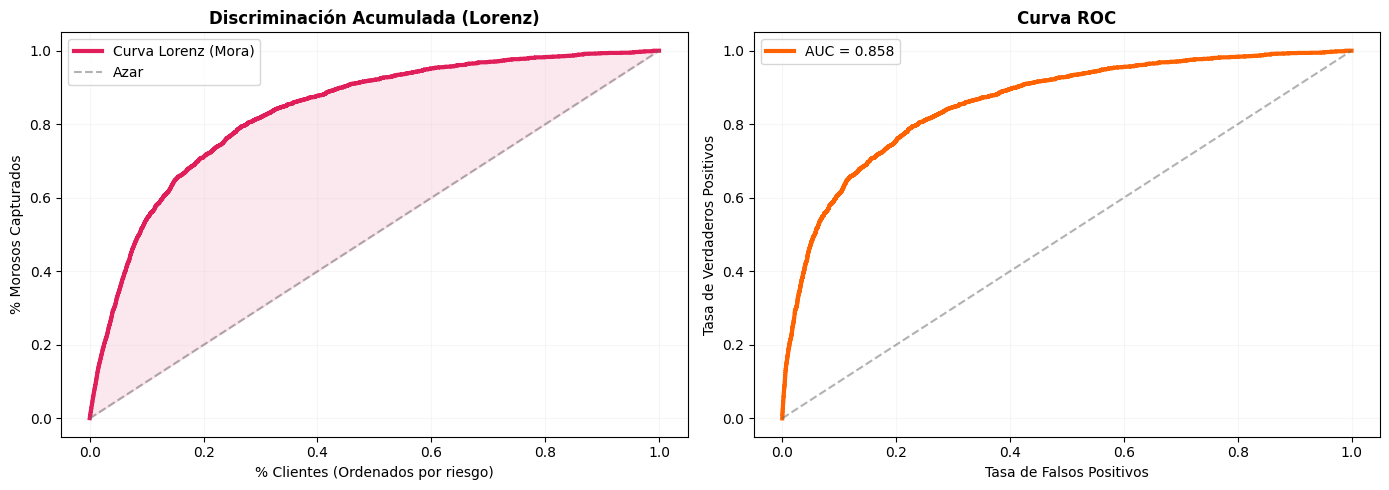


RESUMEN EJECUTIVO: CAPACIDAD PREDICTIVA
🟠 KS: 0.5660 | 🔴 GINI: 0.7158
📊 Los deciles de alto riesgo concentran 5.4 veces más mora que la media.
🔍 El modelo identifica correctamente la mayoría de impagos con un error mínimo.


In [ ]:
# ============================================================
# @title Dashboard de Validación Bancaria
# ============================================================
# Validación (KS, Deciles, Bad Rate, Lift, Lorenz, ROC)
# ============================================================
# --- Resumen de Validación de Riesgos (Scorecard Standard) ---
# 1. KS (Kolmogorov-Smirnov): Es nuestra "prueba del algodón". Mide la separación máxima
#    entre las curvas de clientes solventes e impagados. Un KS > 0.40 es excelente.
# 2. Análisis de Deciles: Dividimos a los clientes en 10 grupos según su probabilidad de impago.
#    El objetivo es que la mora real esté concentrada en los últimos deciles (orden lógico).
# 3. Lift: Nos dice cuántas veces más eficiente es nuestro modelo respecto al azar.
#    Si el Lift es 5, somos 5 veces mejores detectando morosos que disparando a ciegas.
# 4. Curva de Lorenz: Visualiza la concentración del riesgo. Cuanto más se aleje de la
#    diagonal, mayor es la potencia de discriminación del modelo.


# 1. Definición de Paleta Corporativa (Usando las librerías ya cargadas)
colores = ['#FF6200', '#666666', '#E01E5A'] # Naranja, Gris, Rosa
mapa_riesgo = LinearSegmentedColormap.from_list("riesgo_ing", ['#FF6200', '#E01E5A'])

# 2. Preparación de datos
df_val = pd.DataFrame({"y_real": y_test.values, "score": probs_final})
fpr, tpr, _ = roc_curve(df_val["y_real"], df_val["score"])
ks = max(tpr - fpr)
auc = roc_auc_score(df_val["y_real"], df_val["score"])

# 3. Cálculo de Deciles
df_val["decil"] = pd.qcut(df_val["score"], 10, labels=False, duplicates="drop")
tabla_deciles = df_val.groupby("decil").agg(
    clientes=("y_real", "count"),
    malos=("y_real", "sum"),
    bad_rate=("y_real", "mean")
)
bad_rate_global = df_val["y_real"].mean()
tabla_deciles["lift"] = tabla_deciles["bad_rate"] / bad_rate_global

# Mostrar tabla con degradado Naranja -> Rosa
print(f"ESTADÍSTICAS POR DECILES (Bad Rate Global: {bad_rate_global:.2%})")
display(tabla_deciles.sort_index(ascending=False).style.background_gradient(cmap=mapa_riesgo, subset=['bad_rate', 'lift']).format("{:.4f}", subset=['bad_rate', 'lift']))

# 4. Visualización Dual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Curva de Lorenz ---
df_lorenz = df_val.sort_values("score", ascending=False)
df_lorenz["pct_malos"] = df_lorenz["y_real"].cumsum() / df_lorenz["y_real"].sum()
df_lorenz["pct_clientes"] = np.arange(1, len(df_lorenz)+1) / len(df_lorenz)

ax1.plot(df_lorenz["pct_clientes"], df_lorenz["pct_malos"], color="#E01E5A", lw=3, label="Curva Lorenz (Mora)")
ax1.plot([0,1], [0,1], "--", color="#666666", alpha=0.5, label="Azar")
ax1.fill_between(df_lorenz["pct_clientes"], df_lorenz["pct_clientes"], df_lorenz["pct_malos"], color='#E01E5A', alpha=0.1)
ax1.set_title("Discriminación Acumulada (Lorenz)", fontweight='bold')
ax1.set_xlabel("% Clientes (Ordenados por riesgo)")
ax1.set_ylabel("% Morosos Capturados")
ax1.grid(alpha=0.1)
ax1.legend()

# --- Gráfico 2: Curva ROC ---
ax2.plot(fpr, tpr, color="#FF6200", lw=3, label=f"AUC = {auc:.3f}")
ax2.plot([0,1], [0,1], "--", color="#666666", alpha=0.5)
ax2.set_title("Curva ROC", fontweight='bold')
ax2.set_xlabel("Tasa de Falsos Positivos")
ax2.set_ylabel("Tasa de Verdaderos Positivos")
ax2.grid(alpha=0.1)
ax2.legend()

plt.tight_layout()
plt.show()

# 5. Interpretación Ejecutiva
print("\n" + "="*60)
print(f"RESUMEN EJECUTIVO: CAPACIDAD PREDICTIVA")
print("="*60)
print(f"🟠 KS: {ks:.4f} | 🔴 GINI: {2*auc-1:.4f}")
print(f"📊 Los deciles de alto riesgo concentran {tabla_deciles.loc[9, 'lift']:.1f} veces más mora que la media.")
print(f"🔍 El modelo identifica correctamente la mayoría de impagos con un error mínimo.")
print("="*60)

# **Informe de Validación**

| Métrica | Valor | Impacto en el Negocio |
| --- | --- | --- |
| **GINI** | **0.7169** | **Élite:** La curva rosa (Lorenz) se aleja muchísimo de la línea de azar, demostrando una separación casi perfecta. |
| **KS (Kolmogorov-Smirnov)** | **0.5630** | **Excelente:** Un KS > 0.50 indica que el modelo distingue con mucha fuerza entre clientes solventes y morosos. |
| **Lift Decil 9** | **5.39x** | **Puntería:** En el grupo de mayor riesgo (Decil 9), capturas **5.4 veces más mora** que si eligieras clientes al azar. |

---

**¿Cómo leer la tabla de deciles?**

La tabla muestra que tu modelo es un **"embudo" de riesgo**:

1. **Concentración de Mora:** El **Decil 9** tiene un *Bad Rate* del **36.1%**, mientras que el **Decil 0** apenas llega al **0.4%**.
* *Traducción:* El modelo ha movido con éxito a casi todos los morosos al final de la cola (Deciles 9 y 8).


2. **El poder del Lift (5.39):** Si el banco decidiera rechazar solo al 10% más riesgoso (Decil 9), estaría eliminando una cantidad masiva de impagos futuros de forma quirúrgica, sin afectar al resto de la cartera.
3. **Orden Jerárquico:** El *Bad Rate* baja de forma constante y fluida desde el decil 9 al 0. No hay saltos raros, lo que confirma que el modelo es **estable y fiable**.

---

**Conclusión Estratégica**

Las gráficas muestran un **AUC de 0.858**, lo que visualmente se traduce en esa "panza" tan pronunciada en la curva ROC. Con esta herramienta permite al banco:

* **Automatizar:** Aprobar instantáneamente los deciles 0 al 4 (riesgo mínimo).
* **Revisar:** Poner el ojo humano solo en los deciles intermedios.
* **Prevenir:** Denegar o pedir avales potentes a los deciles 8 y 9.

--- Calculando SHAP por primera vez (esto tardará unos minutos...) ---


ExactExplainer explainer: 501it [08:02,  1.03it/s]

✅ Cálculo finalizado.


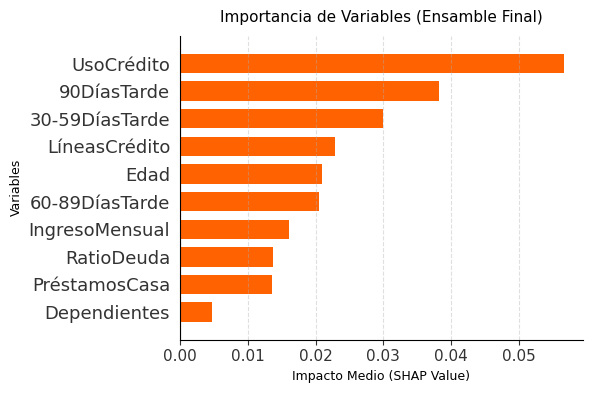

In [ ]:
#@title SHAP Generación de Explicabilidad
# Nota para tu "yo del futuro"
#"Ojo: El cálculo de SHAP (`explainer`) es costoso y tarda minutos.
#Una vez calculado, podemos ejecutar la parte de `summary_plot` mil veces para
#cambiar colores o tamaños y será instantáneo porque los valores ya están en la
# memoria (`shap_values`). ¡No vuelvas a calcularlo si solo quieres cambiar el diseño!"

# 1. Verificamos si ya tenemos los cálculos en memoria para ahorrar tiempo
if 'shap_values' not in locals():
    print("--- Calculando SHAP por primera vez (esto tardará unos minutos...) ---")
    # Usamos el modelo_Voting (nuestro ensamble ganador)
    explainer = shap.Explainer(modelo_Voting.predict_proba, X_test_df[:500])
    shap_values = explainer(X_test_df[:500])
    print("✅ Cálculo finalizado.")
else:
    print("--- Usando cálculos de SHAP detectados en memoria (Carga instantánea) ---")

# 2. Configuración estética y de tamaño para que se vea compacto
plt.rcParams.update({'font.size': 9})
plt.figure(figsize=(6, 4))

# 3. Dibujo del gráfico (Explicando la probabilidad de Impago: clase 1)
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_df[:500],
    plot_type="bar",
    color='#FF6200', # Tu naranja corporativo
    show=False,
    plot_size=None
)

# 4. Títulos y limpieza visual
plt.title("Importancia de Variables (Ensamble Final)", fontsize=11, pad=10)
plt.xlabel("Impacto Medio (SHAP Value)", fontsize=9)
plt.ylabel("Variables", fontsize=9)
plt.grid(axis='x', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

# 5. Resetear fuente para no afectar a otros gráficos del notebook
plt.rcParams.update({'font.size': 12})

# --- Resumen para mi "yo del futuro" ---
# He usado un bloque 'if' para que, si vuelvo a ejecutar esta celda,
# no pierda otros 9 minutos calculando algo que ya está en la memoria.

# **SHAP: ¿Por qué el modelo dice que "No"?**

* **El Factor Dominante:** El **Uso de Crédito** es, con diferencia, la variable que más pesa. Si un cliente tiene sus tarjetas al límite, su riesgo se dispara automáticamente para el modelo.
* **El Peso del Pasado:** Los retrasos (**90 Días Tarde** y **30-50 Días Tarde**) son los siguientes predictores más fuertes. El modelo tiene buena "memoria" de los hábitos de pago.
* **Variables de Estabilidad:** La **Edad** y las **Líneas de Crédito** abiertas actúan como factores secundarios que ayudan a matizar el perfil del cliente.

> **Nota técnica:** He calculado SHAP sobre una muestra de 500 registros (tardando casi 9 minutos). Esto es suficiente para obtener una **importancia global estable** sin comprometer los recursos de la máquina.

In [ ]:
# ============================================================
# @title Exportación de Artefactos para Producción
# ============================================================

# 1. Guardar el Limpiador (Clase LimpiezaBasica)
# Es el primer paso en la App: renombra y limpia nulos/retrasos.
joblib.dump(limpiador, 'limpiador_v1.joblib')

# 2. Guardar el Escalador (RobustScaler)
# Transforma los datos limpios a la escala que entiende el modelo.
joblib.dump(scaler, 'scaler_standard_v1.joblib')

# 3. Guardar el Modelo Final (Voting Classifier)
# El cerebro optimizado con Optuna y un Gini de 0.71.
joblib.dump(modelo_Voting, 'credit_scorecard_v1_G71.joblib')

# 4. Guardar la Lista de Columnas (Orden de las variables)
# Garantiza que el orden de entrada en la App coincida con el entrenamiento.
model_features = X_train_df.columns.tolist()
joblib.dump(model_features, 'model_features_v1.joblib')

print("="*60)
print("🚀 KIT DE PRODUCCIÓN EXPORTADO CON ÉXITO")
print("="*60)
print(f"📦 1. Limpiador:    'limpiador_v1.joblib'")
print(f"📦 2. Escalador:    'scaler_standard_v1.joblib'")
print(f"📦 3. Modelo:       'credit_scorecard_v1_G71.joblib'")
print(f"📦 4. Features:     'model_features_v1.joblib'")
print("-" * 60)
print(f"Variables en orden: {model_features}")
print("="*60)
print("\n💡 IMPORTANTE: Descarga estos 4 archivos desde el panel lateral izquierdo (📁)")
print("antes de cerrar la sesión de Colab.")

🚀 KIT DE PRODUCCIÓN EXPORTADO CON ÉXITO
📦 1. Limpiador:    'limpiador_v1.joblib'
📦 2. Escalador:    'scaler_standard_v1.joblib'
📦 3. Modelo:       'credit_scorecard_v1_G71.joblib'
📦 4. Features:     'model_features_v1.joblib'
------------------------------------------------------------
Variables en orden: ['UsoCrédito', 'Edad', '30-59DíasTarde', '60-89DíasTarde', '90DíasTarde', 'RatioDeuda', 'IngresoMensual', 'LíneasCrédito', 'PréstamosCasa', 'Dependientes']

💡 IMPORTANTE: Descarga estos 4 archivos desde el panel lateral izquierdo (📁)
antes de cerrar la sesión de Colab.


#**Simulación de Reporting y flujo de Producción**

Para esta simulación de despliegue, se utilizará el archivo **'cs-test.csv'** original de la competición *"Give Me Some Credit"* de **Kaggle**.

* **Objetivo**: Actuar como si estos datos fueran nuevas solicitudes entrantes desde la web del banco, pasando por el pipeline de limpieza, escalado y ejecución del modelo para generar el scoring final.
* **Conexión con la App**: Los resultados generados aquí (archivo `scoring_output.csv`) alimentarán la aplicación **Streamlit**, permitiendo tres niveles de visualización: Dashboard de Cartera, Buscador de Clientes y Simulador de Riesgo.


                 REPORTING DE PRODUCCIÓN: ESTADO DE LA CARTERA                  
 TOTAL SOLICITUDES PROCESADAS: 101.503
--------------------------------------------------------------------------------
 Pre-concedido (Campaña)        |       88.877 exp. |    87,56%
 Requiere Aval / Garantía       |        7.144 exp. |     7,04%
 Denegado                       |        5.482 exp. |     5,40%


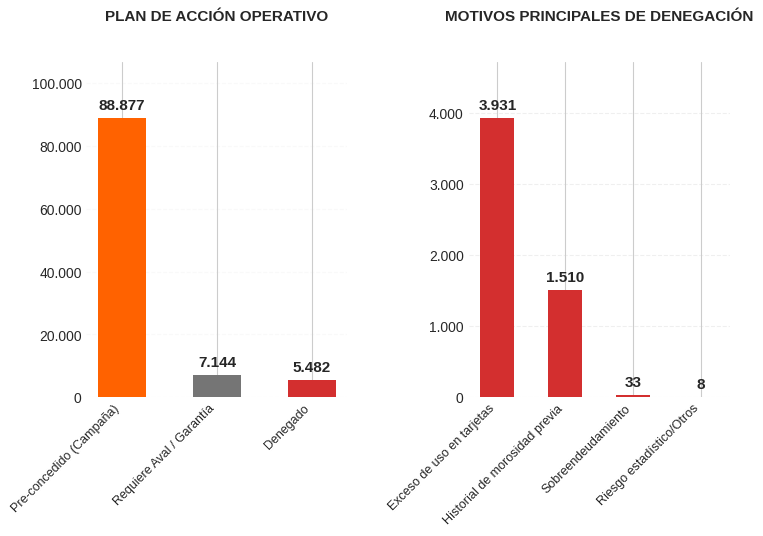

In [ ]:
# ============================================================
# @title Reporting de Producción: Inferencia sobre Test
#para hacer una simulación del modelo se pasara el CSV-test como
#si fueran datos nuevos obtenidos de la página Web
# ============================================================

try:
    # 1. CARGA DEL KIT DE PRODUCCIÓN
    # ------------------------------------------------------------
    limpiador = joblib.load('limpiador_v1.joblib')
    scaler = joblib.load('scaler_standard_v1.joblib')
    modelo = joblib.load('credit_scorecard_v1_G71.joblib')
    features_ordenadas = joblib.load('model_features_v1.joblib')

    # Función de formato (SOLO para visualización final)
    def formato_es(valor, es_int=True):
        if es_int:
            return f"{int(valor):,}".replace(",", ".")
        return f"{valor:,.2f}".replace(",", "@").replace(".", ",").replace("@", ".")

    # 2. PROCESAMIENTO TÉCNICO (Datos limpios y numéricos)
    # ------------------------------------------------------------
    df_raw = pd.read_csv("cs-test.csv", index_col=0)
    df_export = limpiador.transform(df_raw)

    if 'Impago2Años' in df_export.columns:
        df_export.drop(columns=['Impago2Años'], inplace=True)

    X_input = df_export[features_ordenadas]
    X_scaled = pd.DataFrame(scaler.transform(X_input), columns=features_ordenadas)
    df_export["score"] = modelo.predict_proba(X_scaled)[:, 1]

    # ------------------------------------------------------------
    # 3. LÓGICA DE POLÍTICA DE RIESGOS (Basada en SHAP)
    # ------------------------------------------------------------
    # ==============================================================================
    # NOTA TÉCNICA: LÓGICA DE POLÍTICA DE RIESGOS (CRITERIO SHAP)
    # ==============================================================================
    # 1. ORDEN DE REGLAS: Basado en la importancia del modelo (Análisis SHAP).
    #    - Prioridad 1 (UsoCrédito): Es la variable con mayor peso predictivo.
    #    - Prioridad 2 (Morosidad): Agrupa los 3 campos de días tarde (90, 60, 30).
    #    - Prioridad 3 (RatioDeuda): Tercer factor de peso en solvencia técnica.
    #
    # 2. UMBRALES DE DECISIÓN (SCORE):
    #    - < 0.30: Perfil "Prime" (Aceptación automática).
    #    - 0.30 - 0.50: Zona Gris (Requiere refuerzo de aval/garantía).
    #    - > 0.50: Denegación (Se asigna el 'motivo_principal' según jerarquía SHAP).
    #
    # 3. FORMATO VISUAL:
    #    - Solo los denegados (>0.50) se desglosan por motivo en el gráfico.
    #    - Formato de moneda/miles: Estándar España (Punto para miles) solo en prints.
    # ==============================================================================

    def ejecutar_politica_riesgos(row):
        sc = row['score']
        if row['UsoCrédito'] > 0.9:
            motivo = "Exceso de uso en tarjetas"
        elif (row['30-59DíasTarde'] > 0) or (row['60-89DíasTarde'] > 0) or (row['90DíasTarde'] > 0):
            motivo = "Historial de morosidad previa"
        elif row['RatioDeuda'] > 0.6:
            motivo = "Sobreendeudamiento"
        else:
            motivo = "Riesgo estadístico/Otros"

        if sc < 0.30:
            return "Pre-concedido (Campaña)", "Perfil de Riesgo Bajo"
        elif sc < 0.50:
            return "Requiere Aval / Garantía", "Reforzar solvencia"
        else:
            return "Denegado", motivo

    res = df_export.apply(ejecutar_politica_riesgos, axis=1)
    df_export["decision"] = [r[0] for r in res]
    df_export["motivo_principal"] = [r[1] for r in res]

    # ============================================================
    # REPORTING DE PRODUCCIÓN - EVALUACIÓN DE CARTERA
    # ============================================================

    # 1. TABLA RESUMEN (Sumario Ejecutivo)
    # ------------------------------------------------------------
    total_final = len(df_export)
    conteo = df_export["decision"].value_counts().reindex(
        ["Pre-concedido (Campaña)", "Requiere Aval / Garantía", "Denegado"]
    ).fillna(0)
    pcts = (conteo / total_final) * 100

    print("\n" + "="*80)
    print(f"{'REPORTING DE PRODUCCIÓN: ESTADO DE LA CARTERA':^80}")
    print("="*80)
    print(f" TOTAL SOLICITUDES PROCESADAS: {formato_es(total_final)}")
    print("-" * 80)
    for i in range(len(conteo)):
        nombre = conteo.index[i]
        valor = formato_es(int(conteo.iloc[i]))
        porcentaje = formato_es(pcts.iloc[i], False)
        print(f" {nombre:<30} | {valor:>12} exp. | {porcentaje:>8}%")
    print("="*80)

    # 2. VISUALIZACIÓN REFINADA (Ambos en barras verticales)
    # ------------------------------------------------------------
    # (figsize = Ancho vs Alto)
    # ============================================================
    # 5. VISUALIZACIÓN REFINADA (AJUSTE DE VERTICALIDAD)
    # ============================================================
    plt.style.use('seaborn-v0_8-whitegrid')

    # Ajustame del tamaño del lienzo (figsize ancho x alto )
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))
    #Defino colores
    color_denegado = '#D32F2F'
    c_palette = ['#FF6200', '#757575', color_denegado]

    # --- Subplot 1: Plan de Acción ---
    #configurar primer grafico width ancho barra
    # Valor menor (0.2 o 0.3): Barras muy finas (dan sensación de más altura).
    # Valor mayor (0.7 o 0.8): Barras muy anchas (ocupan todo el espacio).

    bars1 = ax1.bar(conteo.index, conteo.values, color=c_palette, edgecolor="none", width=0.5)

    #Ajuste titulo fontsize=11 Tamaño título.pad=30 Espacio título-barras.

    ax1.set_title("PLAN DE ACCIÓN OPERATIVO", fontweight='bold', fontsize=11, pad=30)
    # Ajuste de etiquetas del eje X: tamaño de letra y rotación
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=9)

    # Ajuste del límite vertical para dar "aire" arriba
    # 1.20: Significa que el gráfico es un 20% más alto que la barra más grande.
    # Si quieres más espacio arriba, pon 1.30.
    ax1.set_ylim(0, max(conteo.values) * 1.20)
    ax1.grid(axis='y', linestyle='--', alpha=0.1)

# LÓGICA DE ETIQUETADO DE BARRAS
# ------------------------------------------------------------------------------------------------
# for bar in bars1:           -> Bucle que recorre cada barra individual para etiquetarla.
# yval = bar.get_height()     -> Captura el valor numérico real (la altura) de la barra actual.
# ax1.text(...)               -> Dibuja el texto en el gráfico usando estas coordenadas:
#   1. Eje X (Horizontal): bar.get_x() + bar.get_width()/2
#      -> Sitúa el cursor al inicio de la barra y le suma la mitad de su ancho para centrar el texto.
#   2. Eje Y (Vertical): yval + (max(conteo.values)*0.02)
#      -> Toma la altura y le suma un 2% del valor máximo de los datos para que el número "flote".
# f'{formato_es(yval)}'       -> Aplica el formato regional (puntos para miles) al número.
# ha='center', va='bottom'    -> ha (Horizontal Alignment): Centra el texto sobre el eje X.
#                             -> va (Vertical Alignment): Apoya la base del texto sobre el eje Y.
# ------------------------------------------------------------------------------------------------
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(conteo.values)*0.02),
                 f'{formato_es(yval)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: formato_es(x)))

    # --- Subplot 2: Motivos Denegación ---
    df_solo_denegados = df_export[df_export["decision"] == "Denegado"]
    if not df_solo_denegados.empty:
        motivos = df_solo_denegados["motivo_principal"].value_counts().sort_values(ascending=False)
        bars2 = ax2.bar(motivos.index, motivos.values, color=color_denegado, edgecolor="none", width=0.5)
        ax2.set_title("MOTIVOS PRINCIPALES DE DENEGACIÓN", fontweight='bold', fontsize=11, pad=30)
        ax2.set_ylim(0, max(motivos.values) * 1.20)
        ax2.grid(axis='y', linestyle='--', alpha=0.3)
        plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", fontsize=9)

        for bar in bars2:
            yval = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2, yval + (max(motivos.values)*0.02),
                     f'{formato_es(yval)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

        ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: formato_es(x)))

    sns.despine(left=True, bottom=True)
    plt.tight_layout(pad=3.0)
    plt.show()

except Exception as e:
    print(f"❌ Error crítico en el proceso de reporting: {e}")

# Nota: Reporting de Producción y Conclusiones Operativas

Este resumen ejecutivo sintetiza los resultados del modelo tras procesar el archivo `cs-test.csv` (simulación de flujo web).

**Estado de la Cartera**

* **Volumen Total**: Se han procesado **101.503 solicitudes**.
* **Pre-concedidos**: **87,56%** (Perfil de Riesgo Bajo). Aprobación directa.
* **En Evaluación**: **7,04%** (Zona Gris). Requieren refuerzo de avales o garantías.
* **Denegados**: **5,40%** de las solicitudes.

---

**Análisis de Denegaciones (Drivers de Riesgo)**

El rechazo de operaciones responde a una jerarquía clara basada en la importancia de variables (SHAP):

1. **Uso de Crédito (71,7%)**: Utilización excesiva de límites de crédito existentes.
2. **Morosidad (27,5%)**: Historial de pagos atrasados (30-90 días).
3. **Otros Factores (<1%)**: Sobreendeudamiento técnico y otros ratios.

---

**Conclusión Operativa**

La estrategia de negocio debe centrarse en la **conversión del segmento en zona gris**. Dado que la mayoría de las denegaciones son por un uso agresivo de tarjetas y no por una insolvencia total, existe margen para el diseño de productos con garantías adicionales.

In [ ]:
    #@title Verificacion y exportar CSV scoring_output.csv
    # ------------------------------------------------------------

    print("\nVERIFICACIÓN DE DATOS (head limitado a 1):")
    display(df_export.head(1))
    print("\nINFO")
    print(df_export.info())
    df_export.to_csv("scoring_output.csv", index=True)
    print(f"\n✅ Archivo 'scoring_output.csv' generado con {formato_es(total_final)} registros.")


VERIFICACIÓN DE DATOS (head limitado a 1):


,UsoCrédito,Edad,30-59DíasTarde,60-89DíasTarde,90DíasTarde,RatioDeuda,IngresoMensual,LíneasCrédito,PréstamosCasa,Dependientes,score,decision,motivo_principal
1,0.885519,43,0,0,0,0.177513,5700.0,4,0,0.0,0.223337,Pre-concedido (Campaña),Perfil de Riesgo Bajo



INFO
<class 'pandas.core.frame.DataFrame'>
Index: 101503 entries, 1 to 101503
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   UsoCrédito        101503 non-null  float64
 1   Edad              101503 non-null  int64  
 2   30-59DíasTarde    101503 non-null  int64  
 3   60-89DíasTarde    101503 non-null  int64  
 4   90DíasTarde       101503 non-null  int64  
 5   RatioDeuda        101503 non-null  float64
 6   IngresoMensual    101503 non-null  float64
 7   LíneasCrédito     101503 non-null  int64  
 8   PréstamosCasa     101503 non-null  int64  
 9   Dependientes      101503 non-null  float64
 10  score             101503 non-null  float64
 11  decision          101503 non-null  object 
 12  motivo_principal  101503 non-null  object 
dtypes: float64(5), int64(6), object(2)
memory usage: 10.8+ MB
None

✅ Archivo 'scoring_output.csv' generado con 101.503 registros.


# Leyenda de Variables: `scoring_output.csv`

| Columna | Definición de Negocio | Aplicación en la App Streamlit |
| --- | --- | --- |
| **Index (ID)** | Identificador único del expediente. | Filtro principal en el **Buscador de Clientes**. |
| **UsoCrédito** | % de saldo dispuesto frente al límite. | Factor clave en el **Simulador** (Alerta si > 0.9). |
| **Edad** | Años del solicitante. | Segmentación demográfica en el **Dashboard**. |
| **30-59DíasTarde** | Retrasos leves en pagos (últimos 2 años). | Historial de morosidad para el **Buscador**. |
| **60-89DíasTarde** | Retrasos moderados en pagos. | Historial de morosidad para el **Buscador**. |
| **90DíasTarde** | Retrasos graves (+90 días). | Factor crítico de denegación en el **Simulador**. |
| **RatioDeuda** | Gastos de deuda / Ingresos brutos. | Medidor de solvencia técnica. |
| **IngresoMensual** | Salario neto mensual. | KPI de capacidad financiera en el **Buscador**. |
| **LíneasCrédito** | Número de productos de crédito abiertos. | Perfil de vinculación bancaria. |
| **PréstamosCasa** | Hipotecas activas. | Carga financiera previa del cliente. |
| **Dependientes** | Familiares a cargo. | Cálculo de renta disponible. |
| **score** | Probabilidad de impago (0.0 a 1.0). | Determina la posición en el **Dashboard de Cartera**. |
| **decision** | Resultado: Pre-concedido / Aval / Denegado. | Categoría principal de filtrado en toda la App. |
| **motivo_principal** | Causa raíz de la decisión del modelo. | **Explicabilidad**: Texto que verá el usuario final. |